# code to create recall correlation matrices (Figure _?_)

### imports

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
from itertools import zip_longest

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
import seaborn as sns

% matplotlib inline

### set paths

In [2]:
data_dir = '../../data'
ep_traj_dir = f'{data_dir}/models/episodes/trajectories'
ep_eventseg_dir = f'{data_dir}/models/episodes/eventseg-models'
rec_traj_dir = f'{data_dir}/models/recalls/trajectories'
rec_eventseg_dir = f'{data_dir}/models/recalls/eventseg-models'
pickle_dir = f'{data_dir}/pickles'

# create output folder for corrmat figures
corrmats_dir = '../../paper/figures/corrmats'
if not os.path.isdir(corrmats_dir):
    os.mkdir(corrmats_dir)

### load data

In [3]:
# recall trajectories
recall_trajectories = {rectype : {} for rectype in ['atlep1', 'atlep2', 'arrdev', 'delayed', 'prediction']}

for rectype in recall_trajectories.keys():
    rt_dir = os.path.join(rec_traj_dir, rectype)
    for file in [f for f in os.listdir(rt_dir) if f.startswith('debug')]:
        recall_trajectories[rectype][os.path.splitext(file)[0]] = np.load(os.path.join(rt_dir, file))
    
# recall eventseg models
recall_eventsegs = {rectype : {} for rectype in recall_trajectories.keys()}
for rectype in recall_eventsegs.keys():
    rt_dir = os.path.join(rec_eventseg_dir, rectype)
    for file in [f for f in os.listdir(rt_dir) if f.startswith('debug')]:
        fpath = os.path.join(rt_dir, file)
        with open(fpath, 'rb') as f:
            recall_eventsegs[rectype][os.path.splitext(file)[0]] = pickle.load(f)
        
# across-session ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

### functions

In [4]:
def draw_bounds(ax, eventseg_model):
    """
    Draw event boundaries on a temporal correlation matrix heatmap 
    based on based on a fit brainiak.eventseg.event.EventSegment model
    """
    segments = eventseg_model.segments_[0]   
    bounds = np.where(np.diff(np.argmax(segments, axis=1)))[0]
    bounds_aug = np.concatenate(([0],bounds,[segments.shape[0]]))
    for i in range(len(bounds_aug)-1):
        rect = patches.Rectangle((bounds_aug[i], bounds_aug[i]), bounds_aug[i+1]-bounds_aug[i], 
                                 bounds_aug[i+1]-bounds_aug[i], linewidth=1.5, edgecolor='#FFF9AE', 
                                 facecolor='none')
        ax.add_patch(rect)
    return ax

## plot recall temporal correlation matrices

In [5]:
# plot params
cmap = plt.cm.bone_r
sns.set_context('talk')

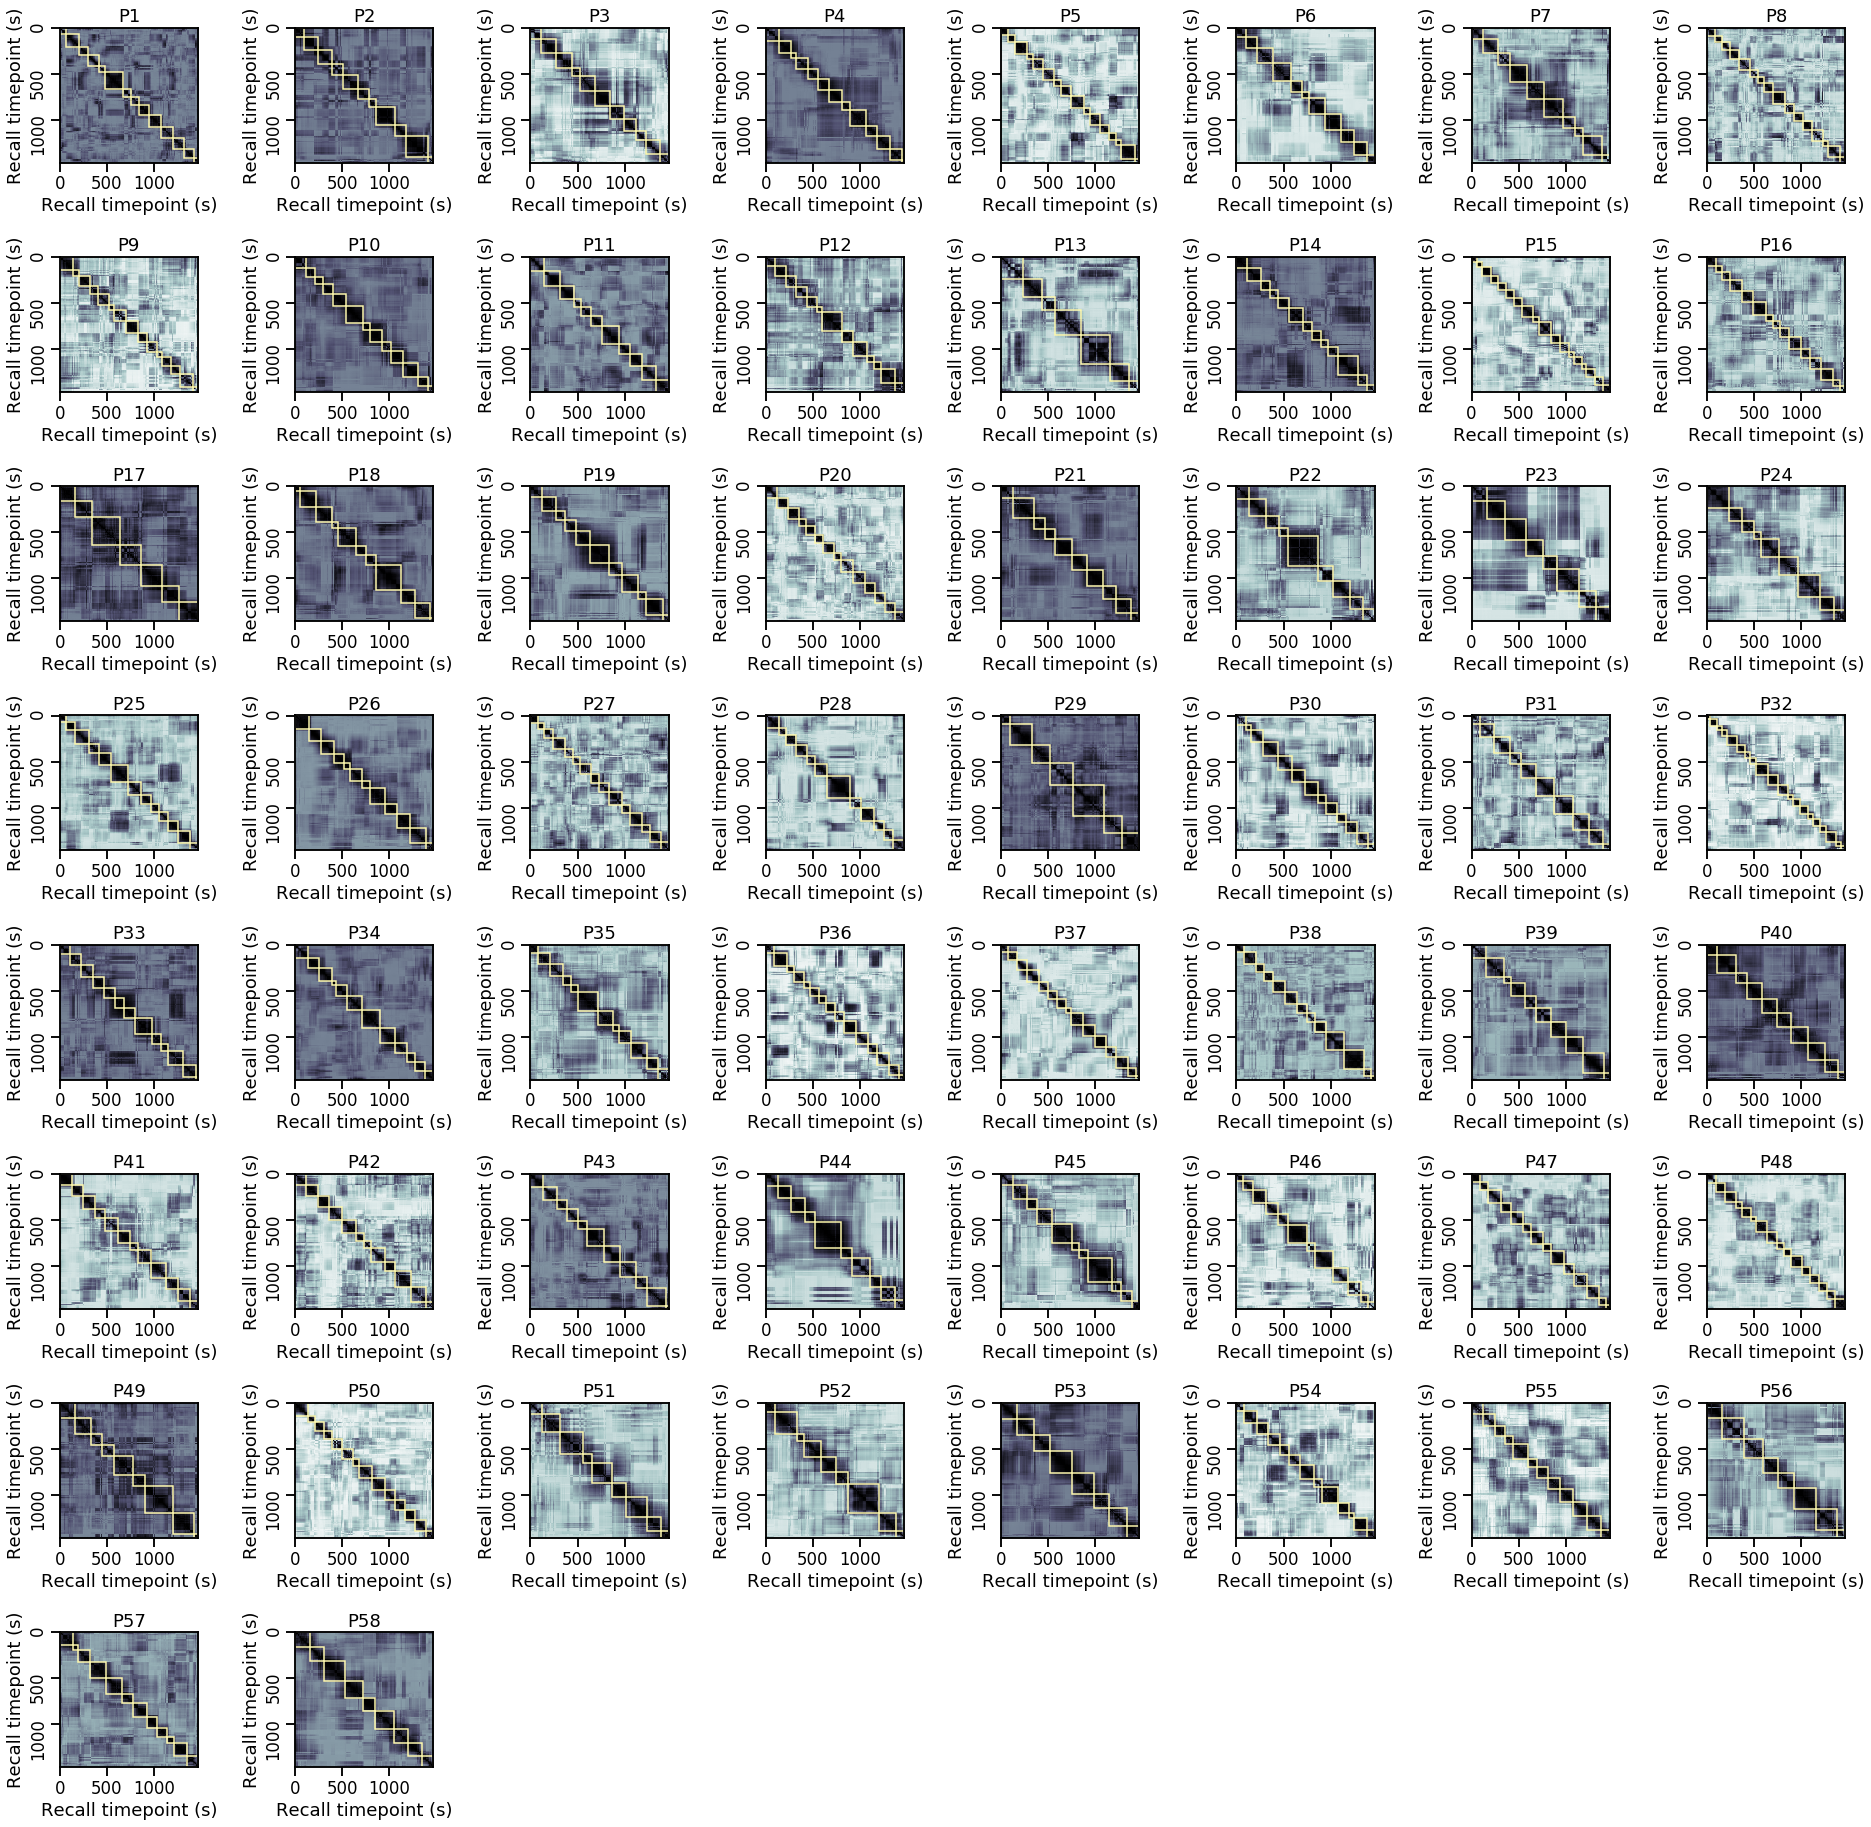

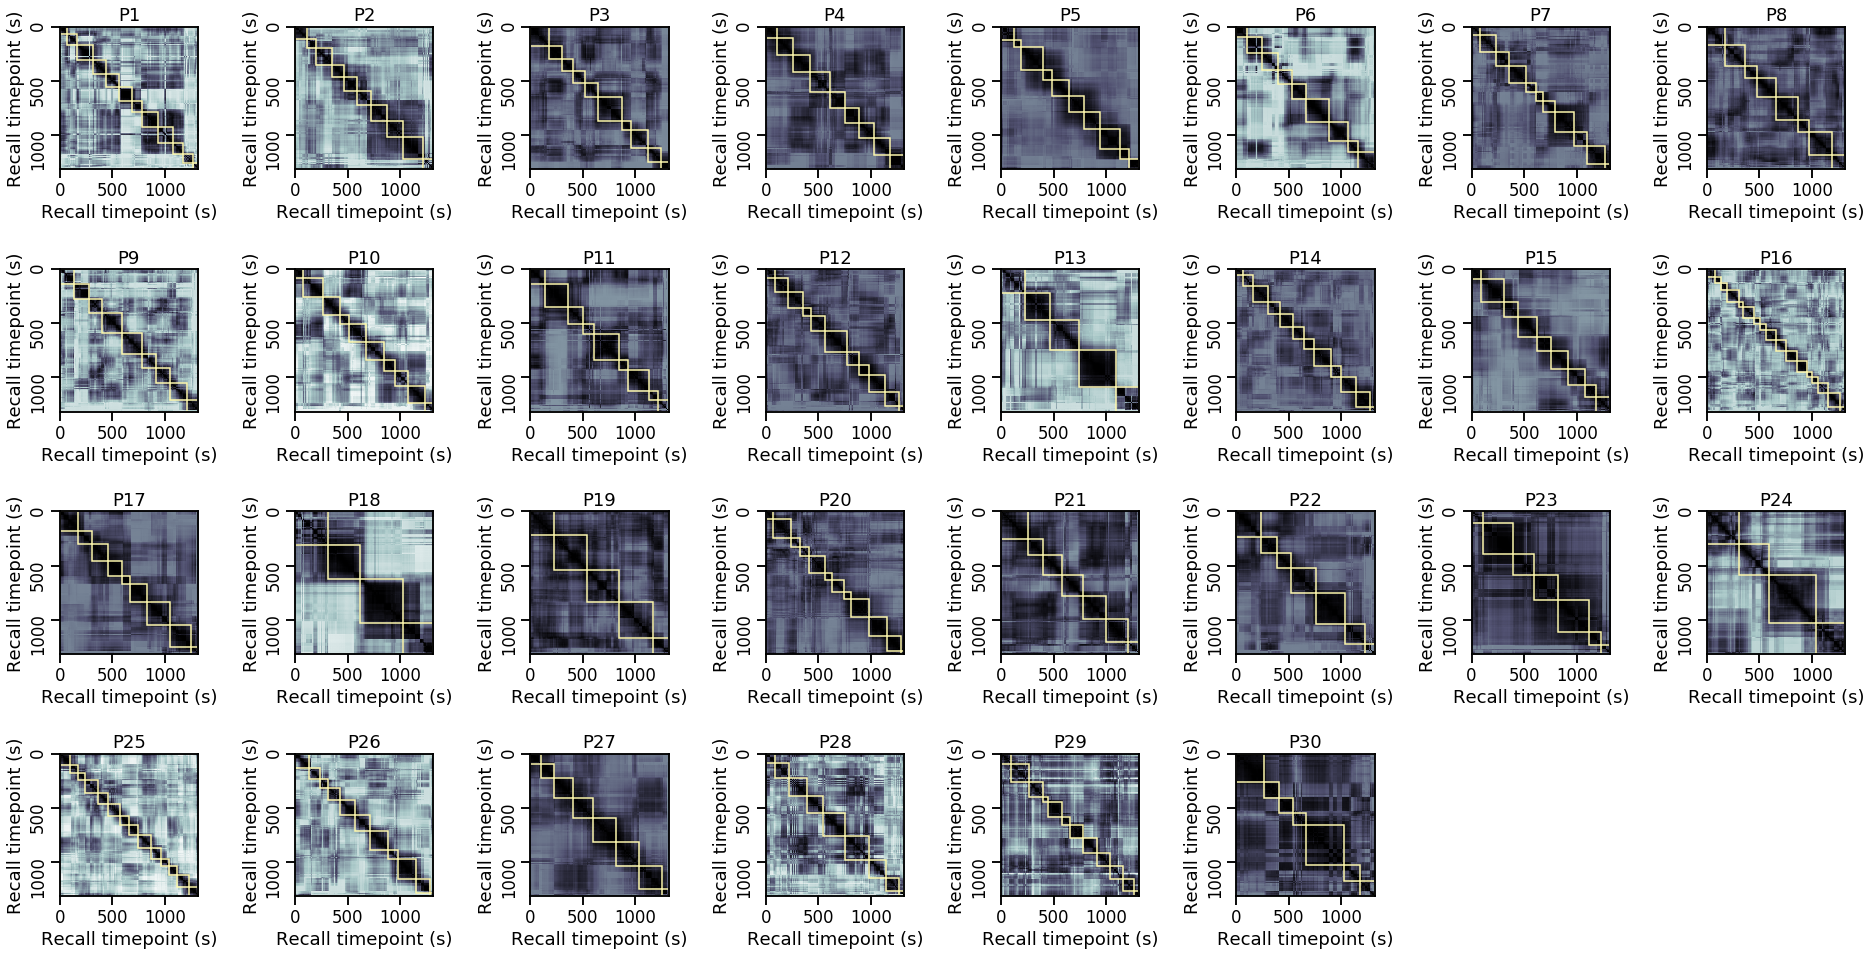

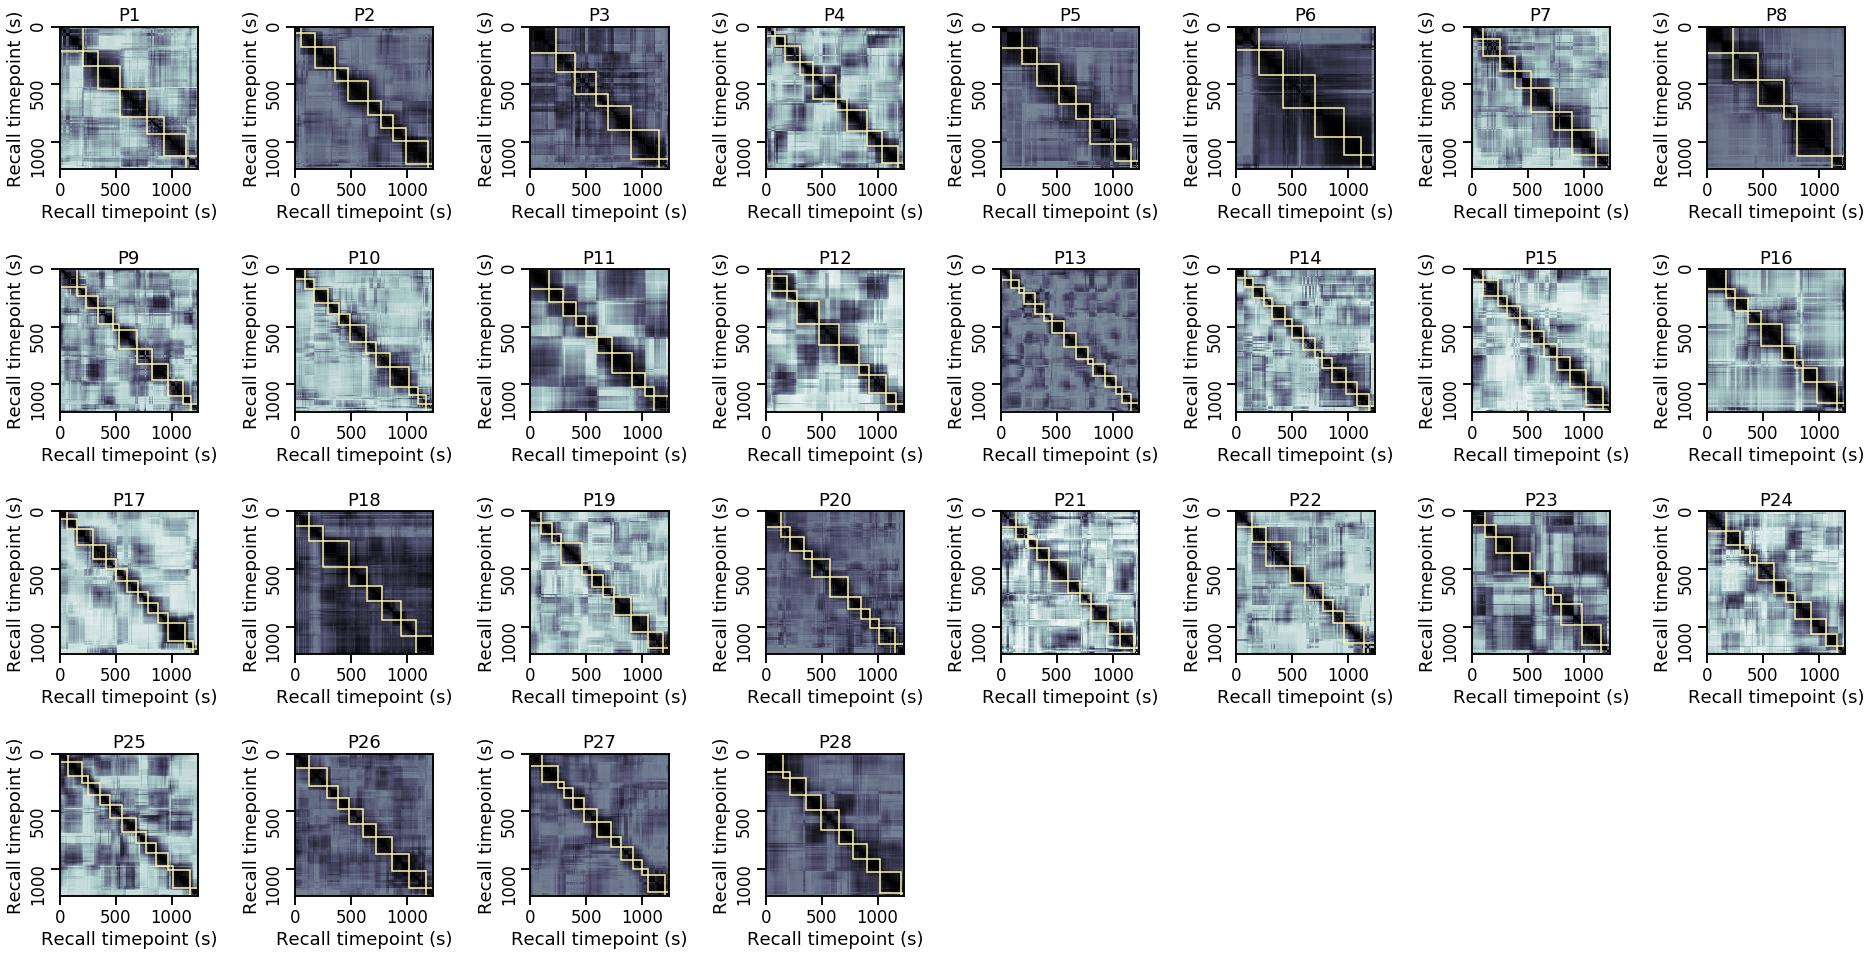

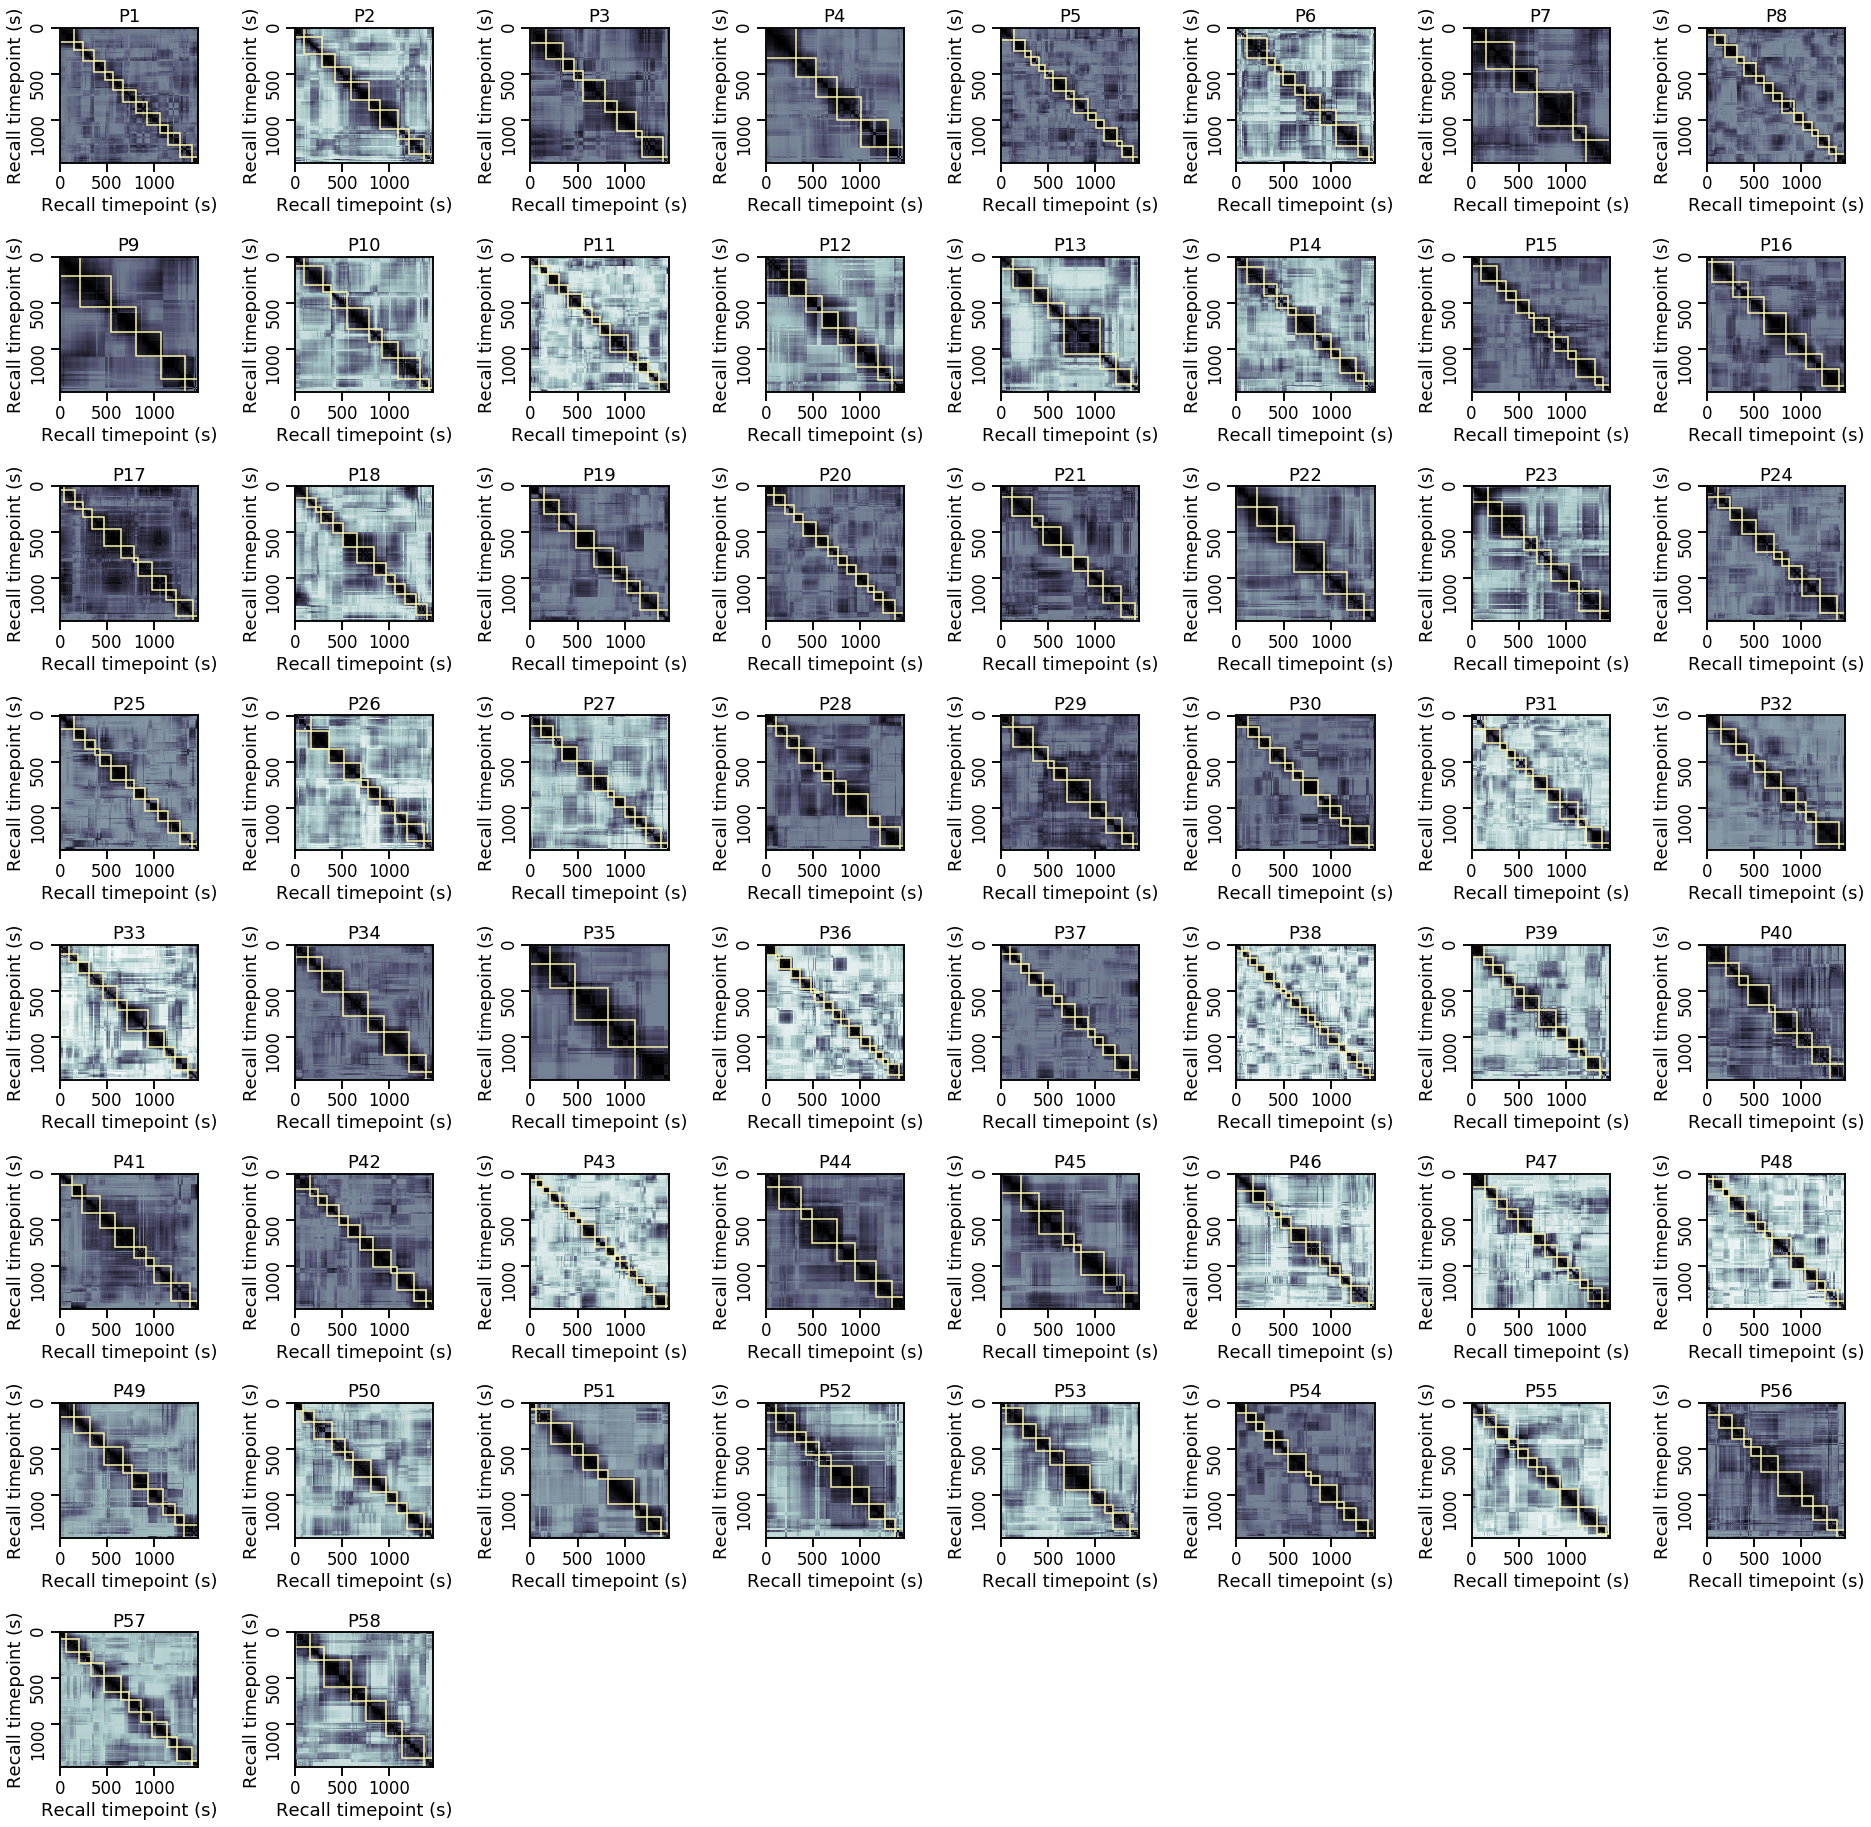

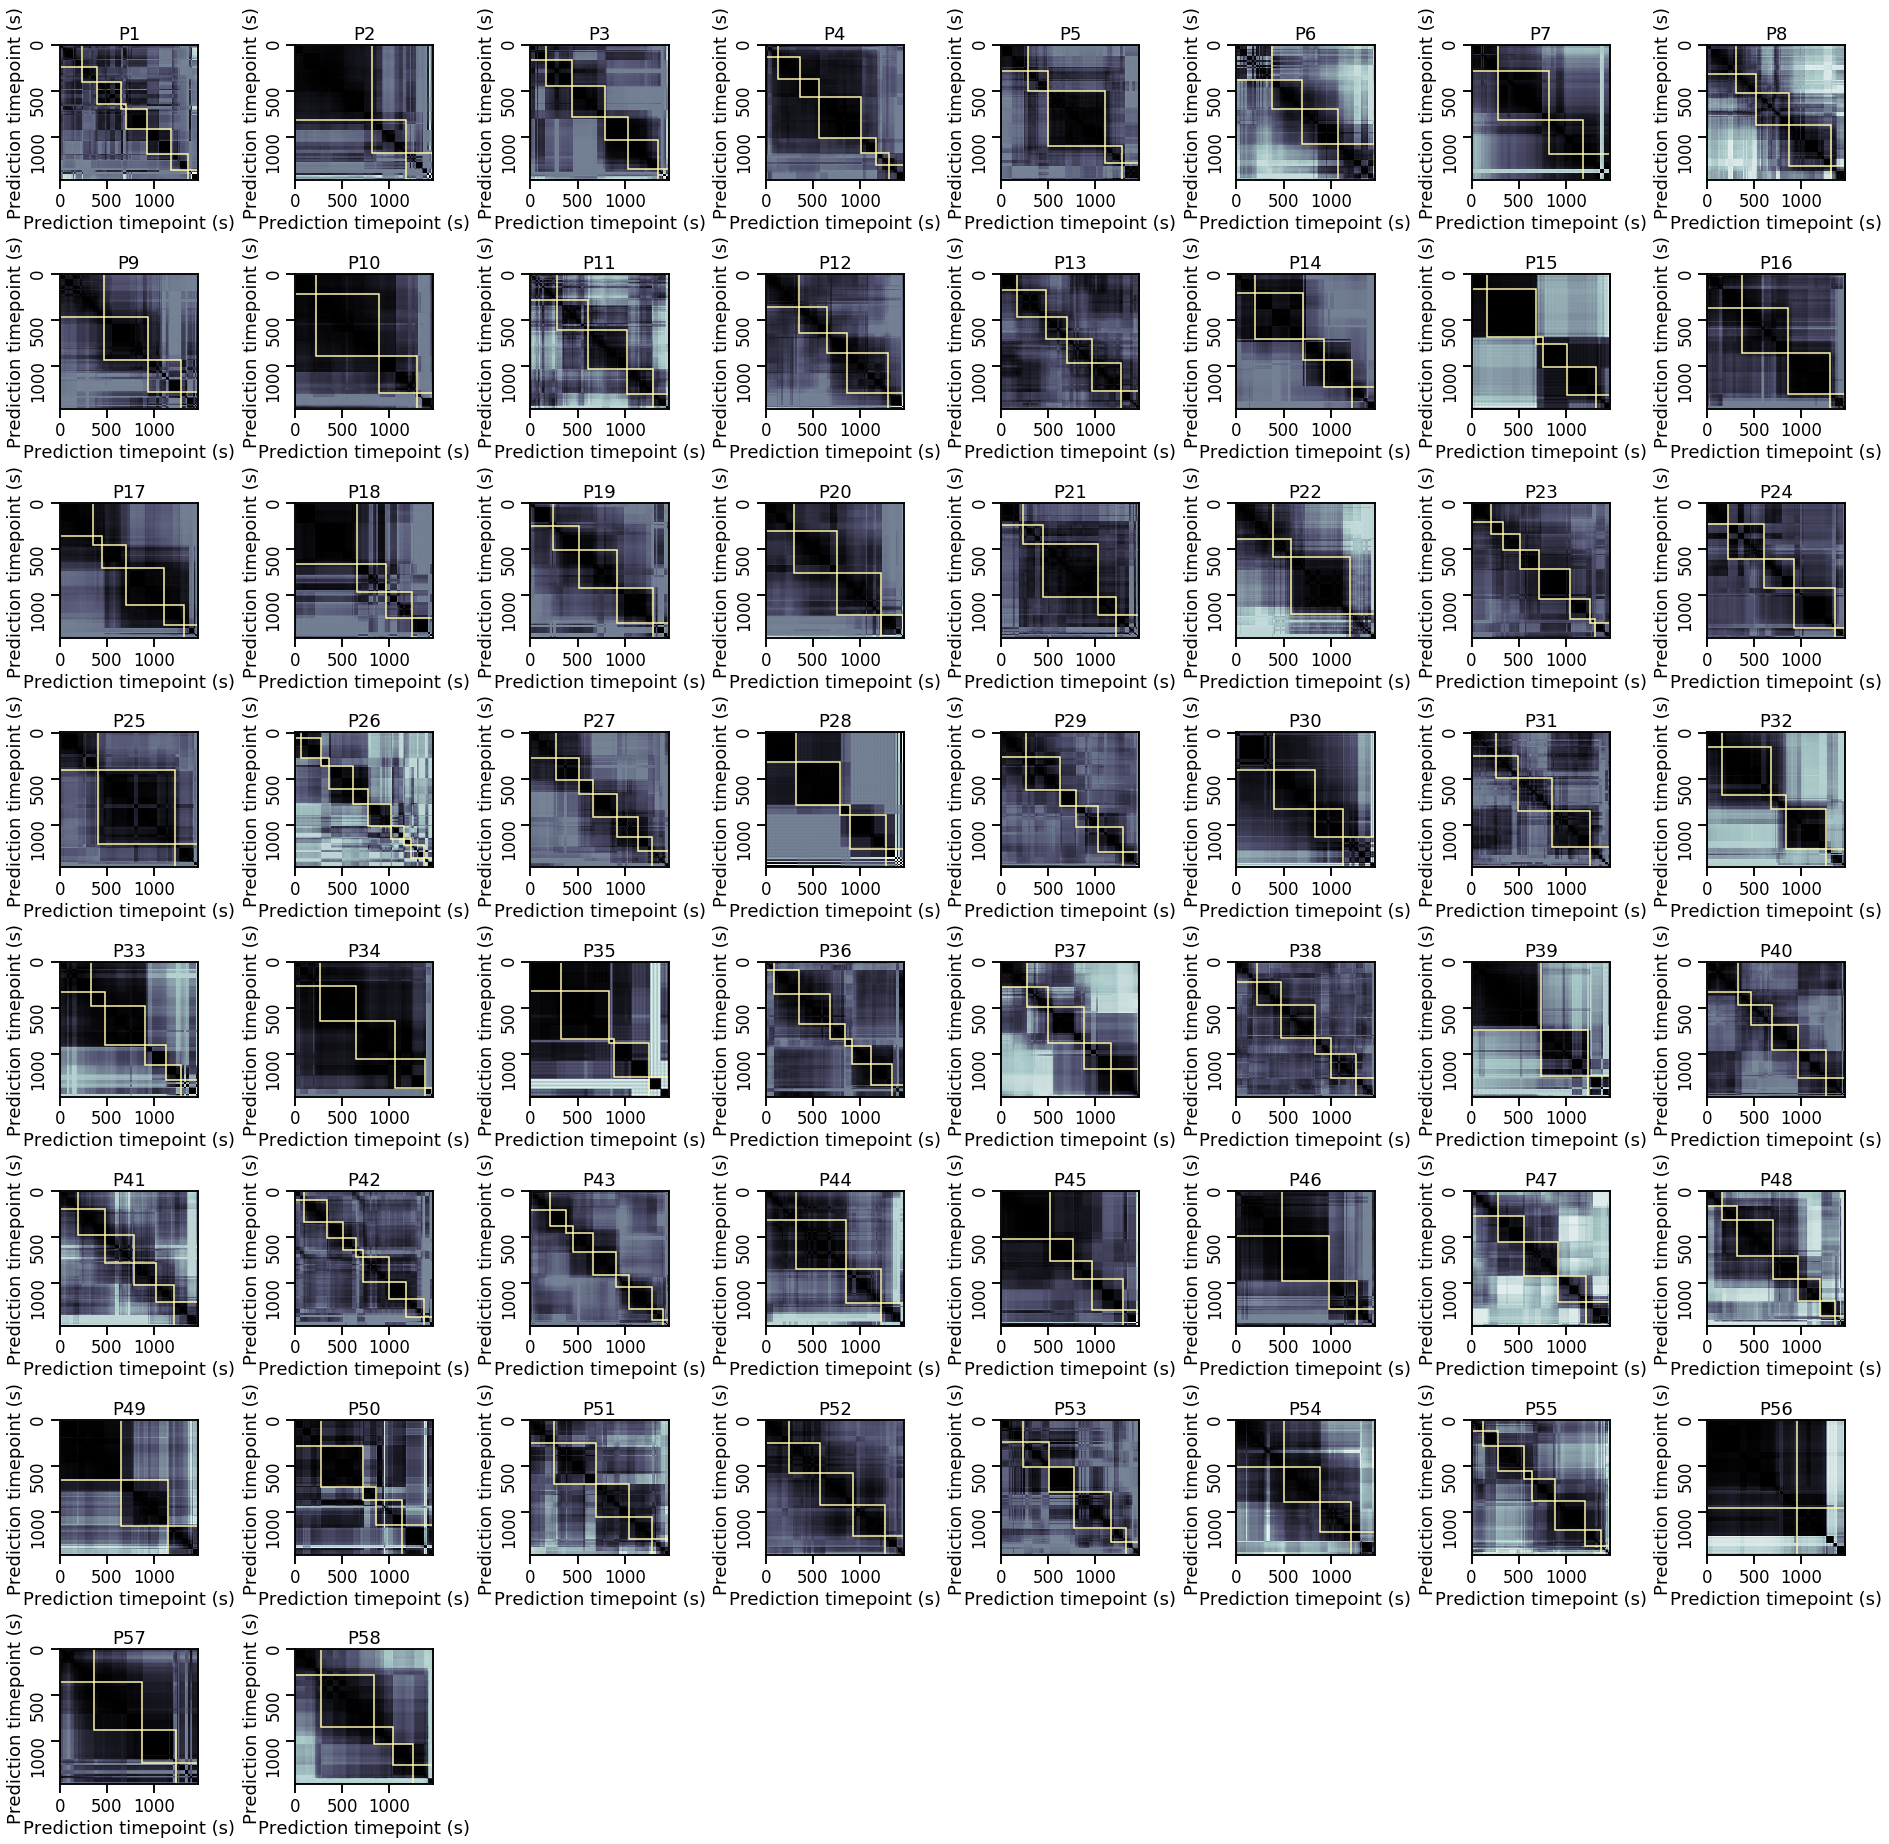

In [6]:
for rectype, r_trajs in recall_trajectories.items():
    fig, axarr = plt.subplots(len(r_trajs)//8 + 1, 8)
    fig.set_size_inches(len(axarr[0])*4,len(axarr)*4)
    axarr = axarr.flatten()
    
    # maintain order of participants across figures
    if rectype in ['atlep1', 'prediction']:
        subs = id_maps['session 1']
    elif rectype == 'atlep2':
        subs = id_maps.loc[id_maps.index.str.contains('A'), 'session 2']
    elif rectype == 'arrdev':
        subs = id_maps.loc[id_maps.index.str.contains('B'), 'session 2']
    else:
        subs = id_maps['session 2']
        
    for i, (ax, sub) in enumerate(zip_longest(axarr, subs)):
        if not sub:
            ax.axis('off')
            continue
        
        traj = r_trajs[sub]
        eventseg = recall_eventsegs[rectype][sub]
        rt = rectype.capitalize() if rectype == 'prediction' else 'Recall'
    
        data = pd.DataFrame(traj).T.corr()
        ax = sns.heatmap(data, cmap=cmap, xticklabels=500, yticklabels=500, vmin=0, vmax=1, cbar=False, ax=ax)
        ax.set_xlabel(f'{rt} timepoint (s)')
        ax.set_ylabel(f'{rt} timepoint (s)')
        ax.set_title(f'P{i+1}')
        
        for _, spine in ax.spines.items():
            spine.set_visible(True)
        
        ax.collections[0].remove()
        ax.imshow(data, aspect='auto', cmap=cmap)
        ax = draw_bounds(ax, eventseg)
        
    plt.subplots_adjust(hspace=.7, wspace=.7)
    plt.savefig(os.path.join(corrmats_dir, f'corrmats-{rectype}.pdf'))
    plt.show()        